# Analysing the residual precipitation file we just generated=>

🔁 Latitude is descending → fixing slice
📊 Data shape after slicing: (31, 141, 141)
📊 Color range: -97.08721336313583 to 97.08721336313583


C:\Users\hp\AppData\Local\Temp\ipykernel_8068\995052904.py:156: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.95])


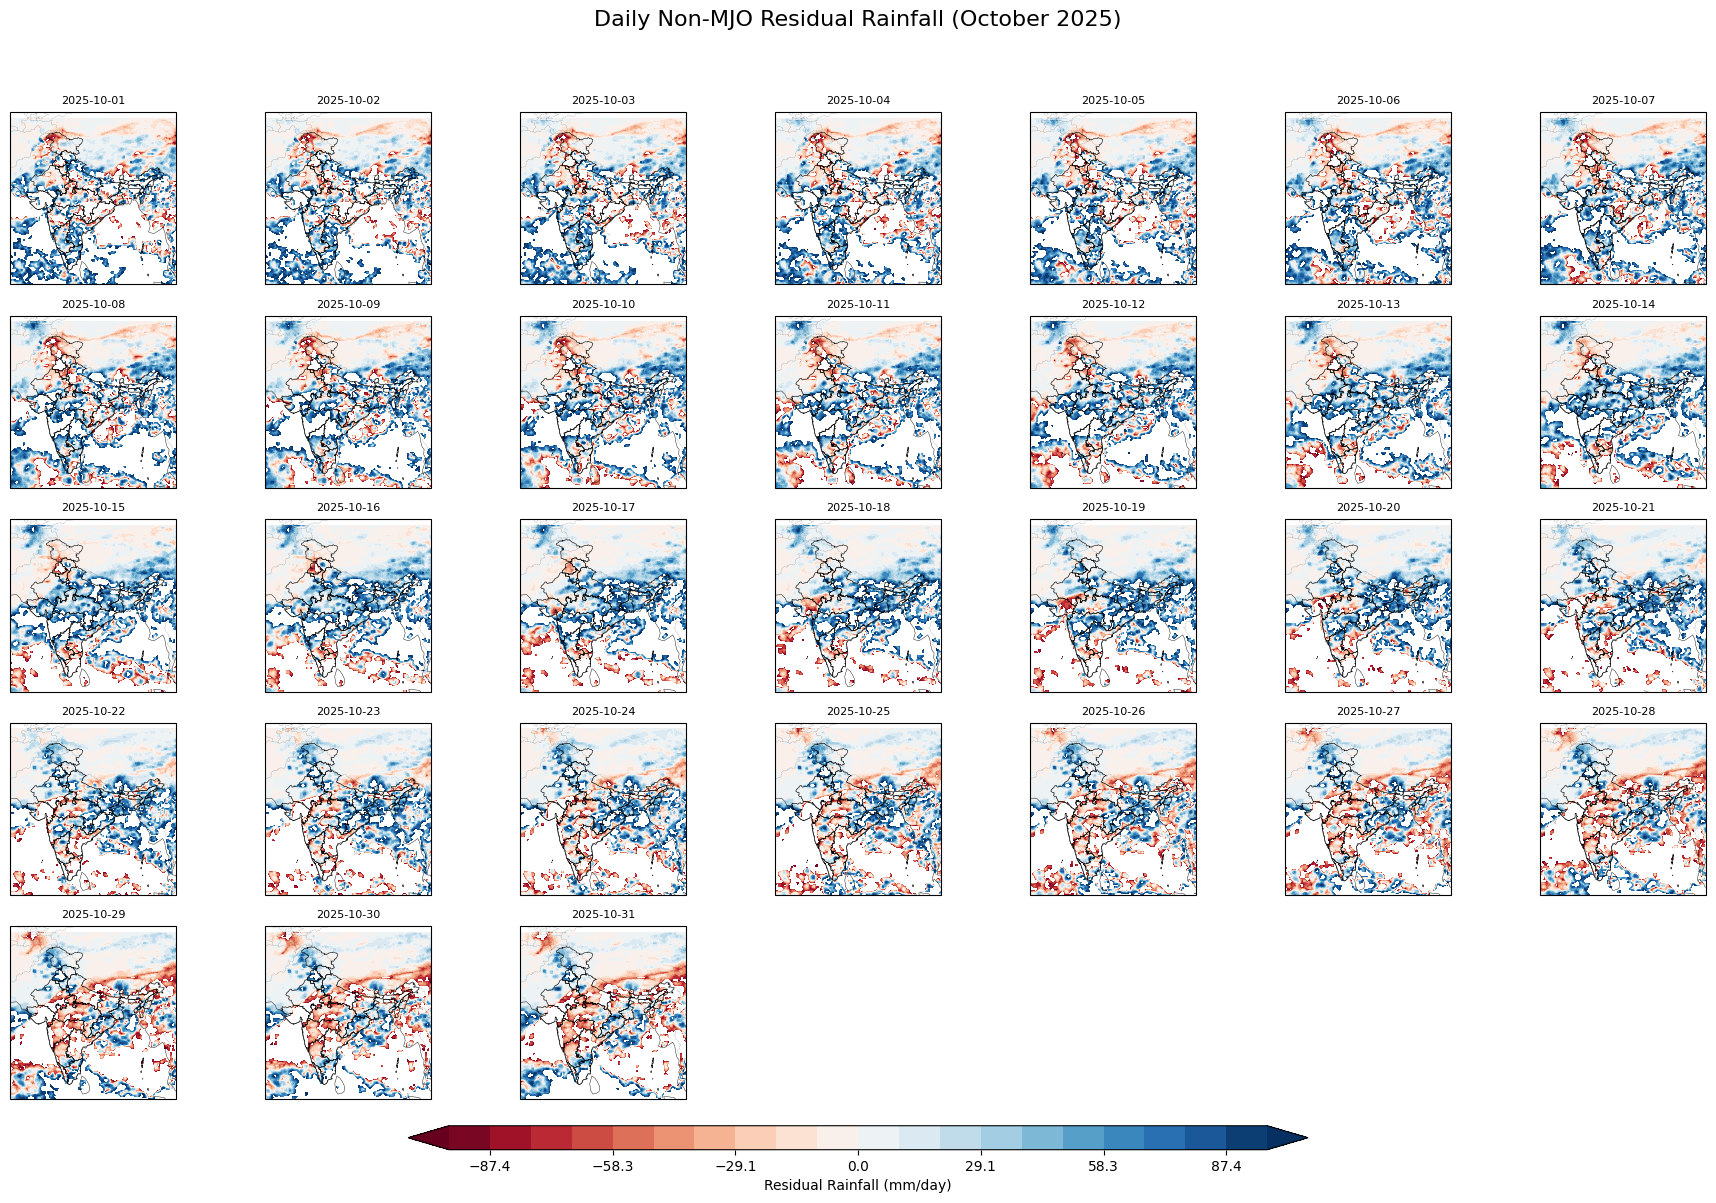

✅ 31-day spatio-temporal plot completed successfully!


In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# =====================================================
# FILE PATHS
# =====================================================

nc_file = r"D:\PHD 2025~\PHD\8.Residual_Prep\non_mjo_oct2025.nc"
shapefile = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# =====================================================
# LOAD DATA
# =====================================================

ds = xr.open_dataset(nc_file)
var_name = list(ds.data_vars)[0]

data = ds[var_name]

# =====================================================
# HANDLE LATITUDE DIRECTION (CRITICAL FIX)
# =====================================================

lat_vals = data.latitude.values

if lat_vals[0] > lat_vals[-1]:
    print("🔁 Latitude is descending → fixing slice")
    data = data.sel(latitude=slice(40, 5), longitude=slice(65, 100))
else:
    print("🔁 Latitude is ascending")
    data = data.sel(latitude=slice(5, 40), longitude=slice(65, 100))

# =====================================================
# CHECK DATA SHAPE
# =====================================================

print("📊 Data shape after slicing:", data.shape)

# =====================================================
# COLOR SCALE (COMMON FOR ALL DAYS)
# =====================================================

data_np = np.where(np.isfinite(data.values), data.values, np.nan)

vmax = np.nanpercentile(np.abs(data_np), 99)

if vmax < 1e-6 or not np.isfinite(vmax):
    vmax = 20

levels = np.linspace(-vmax, vmax, 21)

print("📊 Color range:", -vmax, "to", vmax)

# =====================================================
# FIGURE SETUP
# =====================================================

nrows, ncols = 5, 7  # 35 slots

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(18, 12),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

# =====================================================
# SHAPEFILE
# =====================================================

shape_feature = cfeature.ShapelyFeature(
    shpreader.Reader(shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.4
)

# =====================================================
# PLOTTING LOOP
# =====================================================

cf = None  # for colorbar reference

for i in range(min(31, data.time.size)):

    ax = axes[i]

    data_day = data.isel(time=i)

    # Safety check (VERY IMPORTANT)
    if data_day.shape[0] < 2 or data_day.shape[1] < 2:
        print(f"⚠️ Skipping day {i} (invalid shape {data_day.shape})")
        ax.set_title("No Data")
        ax.set_extent([65, 100, 5, 40])
        continue

    arr = np.where(np.isfinite(data_day.values), data_day.values, np.nan)

    cf = ax.contourf(
        data_day.longitude,
        data_day.latitude,
        arr,
        levels=levels,
        cmap="RdBu",
        extend="both",
        transform=ccrs.PlateCarree()
    )

    # Map features
    ax.add_feature(shape_feature)
    ax.coastlines(resolution='110m', linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.2)

    ax.set_extent([65, 100, 5, 40])

    # Title = date
    date_str = str(data_day.time.values)[:10]
    ax.set_title(date_str, fontsize=8)

# =====================================================
# REMOVE EMPTY SUBPLOTS
# =====================================================

for j in range(31, len(axes)):
    fig.delaxes(axes[j])

# =====================================================
# COLORBAR (BOTTOM CLEAN)
# =====================================================

plt.subplots_adjust(bottom=0.08)

cbar_ax = fig.add_axes([0.25, 0.03, 0.5, 0.02])

if cf is not None:
    cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Residual Rainfall (mm/day)")

# =====================================================
# TITLE
# =====================================================

fig.suptitle("Daily Non-MJO Residual Rainfall (October 2025)", fontsize=16)

# =====================================================
# FINAL
# =====================================================

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

print("✅ 31-day spatio-temporal plot completed successfully!")

🔁 Latitude is descending → fixing slice
📊 Data shape after slicing: (31, 141, 141)
📊 Color range: -97.08721336313583 to 97.08721336313583


C:\Users\hp\AppData\Local\Temp\ipykernel_8068\2504121900.py:171: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 0.95])


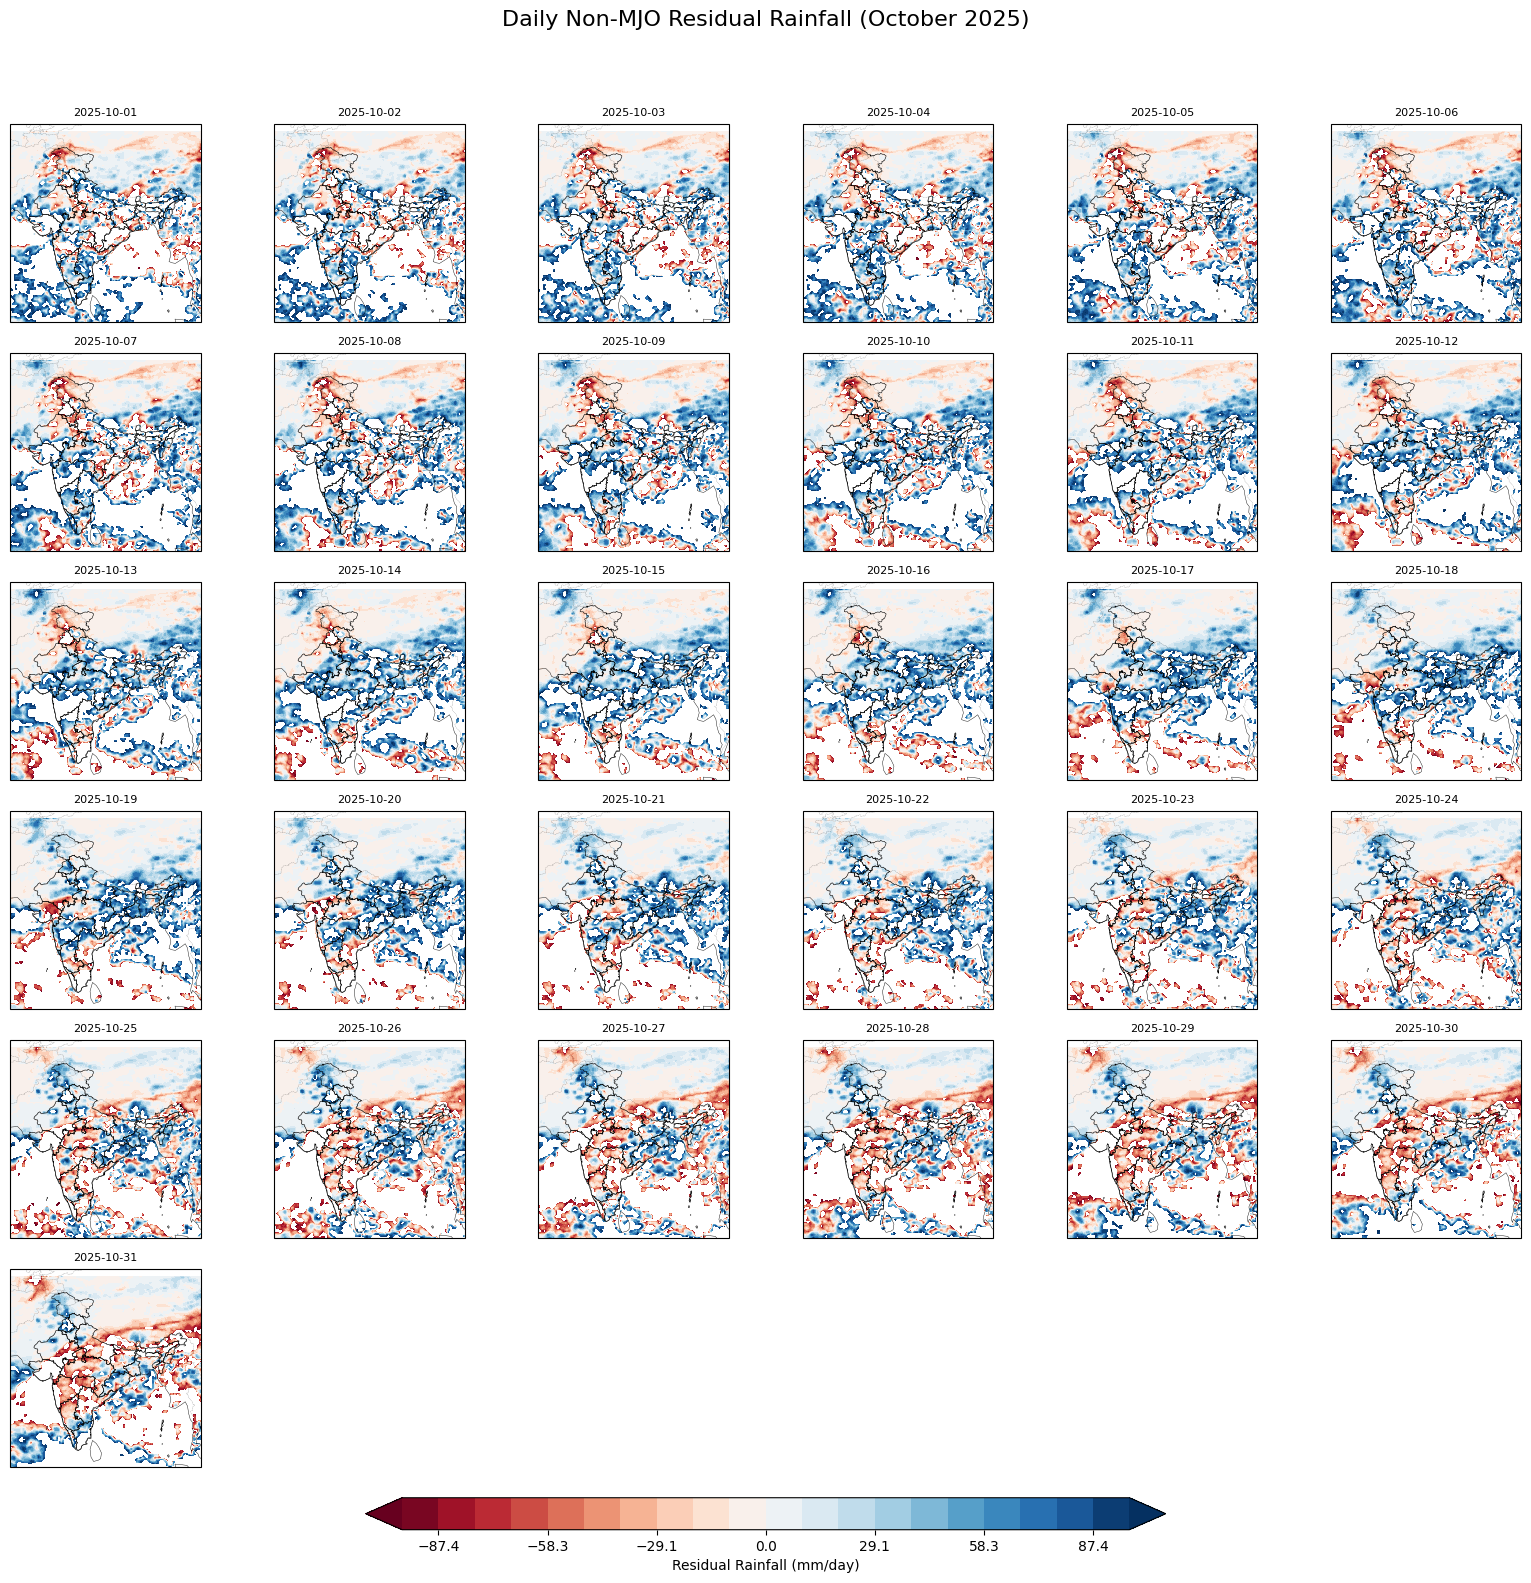

✅ 31-day spatio-temporal plot completed successfully!


In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader

# =====================================================
# FILE PATHS
# =====================================================

nc_file = r"D:\PHD 2025~\PHD\8.Residual_Prep\non_mjo_oct2025.nc"
shapefile = r"D:\PHD 2025~\PHD\Shapefiles\India Shapefile With Kashmir\India Shape\india_st.shp"

# =====================================================
# LOAD DATA
# =====================================================

ds = xr.open_dataset(nc_file)
var_name = list(ds.data_vars)[0]

data = ds[var_name]

# =====================================================
# HANDLE LATITUDE DIRECTION (CRITICAL FIX)
# =====================================================

lat_vals = data.latitude.values

if lat_vals[0] > lat_vals[-1]:
    print("🔁 Latitude is descending → fixing slice")
    data = data.sel(latitude=slice(40, 5), longitude=slice(65, 100))
else:
    print("🔁 Latitude is ascending")
    data = data.sel(latitude=slice(5, 40), longitude=slice(65, 100))

# =====================================================
# CHECK DATA SHAPE
# =====================================================

print("📊 Data shape after slicing:", data.shape)

# =====================================================
# COLOR SCALE (COMMON FOR ALL DAYS)
# =====================================================

data_np = np.where(np.isfinite(data.values), data.values, np.nan)

vmax = np.nanpercentile(np.abs(data_np), 99)

if vmax < 1e-6 or not np.isfinite(vmax):
    vmax = 20

levels = np.linspace(-vmax, vmax, 21)

print("📊 Color range:", -vmax, "to", vmax)

# =====================================================
# FIGURE SETUP
# =====================================================

# nrows, ncols = 5, 7  # 35 slots

fig, axes = plt.subplots(
    nrows=6,
    ncols=6,
    figsize=(16, 16),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

plt.subplots_adjust(
    wspace=0.01,
    hspace=0.25
)



# fig, axes = plt.subplots(
#     nrows=nrows,
#     ncols=ncols,
#     figsize=(18, 12),
#     subplot_kw={'projection': ccrs.PlateCarree()}
# )

axes = axes.flatten()


# =====================================================
# SHAPEFILE
# =====================================================

shape_feature = cfeature.ShapelyFeature(
    shpreader.Reader(shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor='black',
    facecolor='none',
    linewidth=0.4
)

# =====================================================
# PLOTTING LOOP
# =====================================================

cf = None  # for colorbar reference

for i in range(min(31, data.time.size)):

    ax = axes[i]

    data_day = data.isel(time=i)

    # Safety check (VERY IMPORTANT)
    if data_day.shape[0] < 2 or data_day.shape[1] < 2:
        print(f"⚠️ Skipping day {i} (invalid shape {data_day.shape})")
        ax.set_title("No Data")
        ax.set_extent([65, 100, 5, 40])
        continue

    arr = np.where(np.isfinite(data_day.values), data_day.values, np.nan)

    cf = ax.contourf(
        data_day.longitude,
        data_day.latitude,
        arr,
        levels=levels,
        cmap="RdBu",
        extend="both",
        transform=ccrs.PlateCarree()
    )

    # Map features
    ax.add_feature(shape_feature)
    ax.coastlines(resolution='110m', linewidth=0.3)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.2)

    ax.set_extent([65, 100, 5, 40])

    # Title = date
    date_str = str(data_day.time.values)[:10]
    ax.set_title(date_str, fontsize=8)

# =====================================================
# REMOVE EMPTY SUBPLOTS
# =====================================================

for j in range(31, len(axes)):
    fig.delaxes(axes[j])

# =====================================================
# COLORBAR (BOTTOM CLEAN)
# =====================================================

plt.subplots_adjust(bottom=0.08)

cbar_ax = fig.add_axes([0.25, 0.03, 0.5, 0.02])

if cf is not None:
    cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("Residual Rainfall (mm/day)")

# =====================================================
# TITLE
# =====================================================

fig.suptitle("Daily Non-MJO Residual Rainfall (October 2025)", fontsize=16)

# =====================================================
# FINAL
# =====================================================

plt.tight_layout(rect=[0, 0.06, 1, 0.95])
plt.show()

print("✅ 31-day spatio-temporal plot completed successfully!")